In [ ]:
pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 7.6 MB/s eta 0:00:00


0:	learn: 19.4186576	total: 7.02ms	remaining: 2.1s
50:	learn: 13.2412737	total: 298ms	remaining: 1.45s
100:	learn: 10.5961265	total: 543ms	remaining: 1.07s
150:	learn: 8.9598535	total: 717ms	remaining: 708ms
200:	learn: 7.7351070	total: 993ms	remaining: 489ms
250:	learn: 6.9092169	total: 1.24s	remaining: 241ms
299:	learn: 6.2394252	total: 1.46s	remaining: 0us

📊 CatBoost Evaluation on Mar–May 2024
MAE: 9.55
RMSE: 15.54
MSE: 241.46
R²: 0.5786


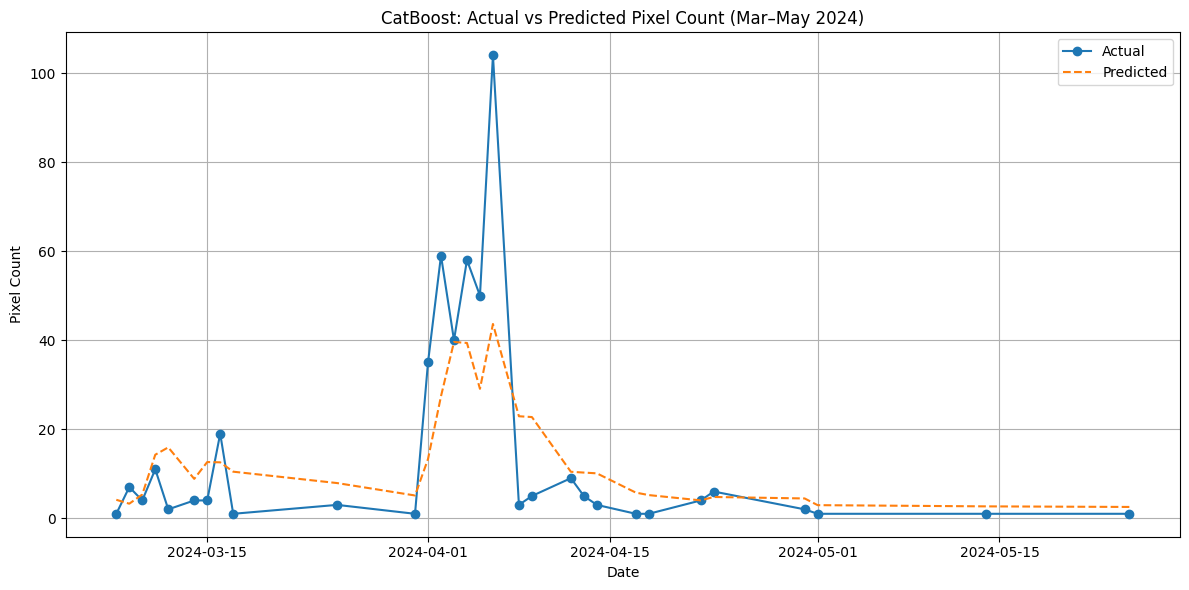

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from catboost import CatBoostRegressor, Pool

# --- Step 1: Load and preprocess training data (2012–2023) ---
train_df = pd.read_csv('/content/drive/MyDrive/Prophet Test/As_DimaHasao_Fire_Metrics_2012_2023.csv', parse_dates=['date'])
train_df['date'] = pd.to_datetime(train_df['date'], dayfirst=True)

# Feature engineering
train_df['day_of_year'] = train_df['date'].dt.dayofyear
train_df['month'] = train_df['date'].dt.month
train_df['year'] = train_df['date'].dt.year
train_df['day_of_week'] = train_df['date'].dt.dayofweek
train_df['week_of_year'] = train_df['date'].dt.isocalendar().week  # Don't cast to int
train_df['is_weekend'] = train_df['day_of_week'].isin([5, 6]).astype(int)

# Lag and rolling features
train_df['lag1'] = train_df['pixel_count'].shift(1)
train_df['lag3'] = train_df['pixel_count'].shift(3)
train_df['lag7'] = train_df['pixel_count'].shift(7)
train_df['rolling7'] = train_df['pixel_count'].rolling(window=7).mean()

train_df.dropna(inplace=True)

# --- Step 2: Load and preprocess 2024 validation data ---
val_df = pd.read_csv('/content/drive/MyDrive/Prophet Test/As_DimaHasao_Fire_Metrics_2024.csv', parse_dates=['date'])
val_df['date'] = pd.to_datetime(val_df['date'], dayfirst=True)
val_df = val_df[val_df['date'].dt.month.isin([3, 4, 5])]

# Same feature engineering on validation set
val_df['day_of_year'] = val_df['date'].dt.dayofyear
val_df['month'] = val_df['date'].dt.month
val_df['year'] = val_df['date'].dt.year
val_df['day_of_week'] = val_df['date'].dt.dayofweek
val_df['week_of_year'] = val_df['date'].dt.isocalendar().week
val_df['is_weekend'] = val_df['day_of_week'].isin([5, 6]).astype(int)

val_df['lag1'] = val_df['pixel_count'].shift(1)
val_df['lag3'] = val_df['pixel_count'].shift(3)
val_df['lag7'] = val_df['pixel_count'].shift(7)
val_df['rolling7'] = val_df['pixel_count'].rolling(window=7).mean()

val_df.dropna(inplace=True)

# --- Step 3: Define features and target ---
features = ['day_of_year', 'month', 'year', 'day_of_week', 'week_of_year', 'is_weekend',
            'lag1', 'lag3', 'lag7', 'rolling7']

X_train = train_df[features]
y_train = train_df['pixel_count']
X_test = val_df[features]
y_test = val_df['pixel_count']

# --- Step 4: Train CatBoost Regressor ---
catboost_model = CatBoostRegressor(
    iterations=300,
    depth=8,
    learning_rate=0.03,
    loss_function='RMSE',
    verbose=50,
    random_seed=42
)

catboost_model.fit(X_train, y_train)

# --- Step 5: Make predictions and evaluate ---
y_pred = catboost_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\n📊 CatBoost Evaluation on Mar–May 2024")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MSE: {mse:.2f}")
print(f"R²: {r2:.4f}")

# --- Step 6: Plot Actual vs Predicted ---
plt.figure(figsize=(12, 6))
plt.plot(val_df['date'], y_test, label='Actual', marker='o')
plt.plot(val_df['date'], y_pred, label='Predicted', linestyle='--')
plt.title('CatBoost: Actual vs Predicted Pixel Count (Mar–May 2024)')
plt.xlabel('Date')
plt.ylabel('Pixel Count')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**2012 to 2023 - predict for 2024, 2012 to 2024, predict for 2025**

In [ ]:
pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 7.8 MB/s eta 0:00:00


0:	learn: 37.1091002	total: 7.29ms	remaining: 2.18s
50:	learn: 24.7120021	total: 270ms	remaining: 1.32s
100:	learn: 17.8997004	total: 551ms	remaining: 1.08s
150:	learn: 13.9054031	total: 881ms	remaining: 869ms
200:	learn: 11.2183792	total: 1.2s	remaining: 589ms
250:	learn: 9.2938947	total: 1.48s	remaining: 289ms
299:	learn: 7.7546827	total: 1.81s	remaining: 0us

📊 CatBoost Evaluation on Mar–May 2024
MAE: 16.05
RMSE: 30.58
MSE: 935.01
R²: 0.1607


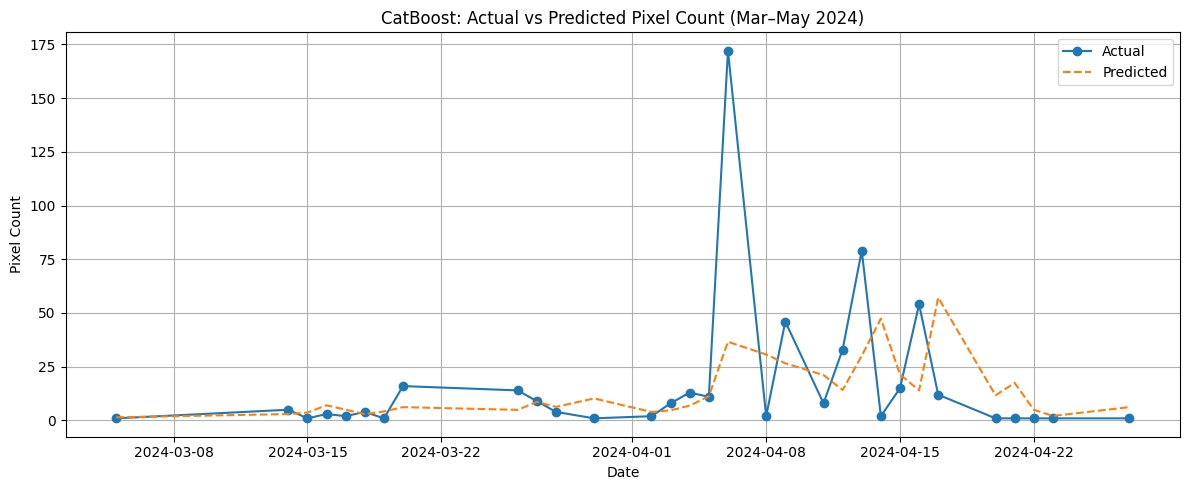

0:	learn: 36.7978234	total: 5.84ms	remaining: 1.75s
50:	learn: 24.6246319	total: 271ms	remaining: 1.32s
100:	learn: 18.1312667	total: 641ms	remaining: 1.26s
150:	learn: 14.4754053	total: 870ms	remaining: 859ms
200:	learn: 11.9755742	total: 982ms	remaining: 484ms
250:	learn: 10.1824795	total: 1.09s	remaining: 214ms
299:	learn: 8.6891666	total: 1.21s	remaining: 0us

📊 CatBoost Evaluation on Mar–May 2025
MAE: 15.43
RMSE: 33.31
MSE: 1109.35
R²: 0.4181


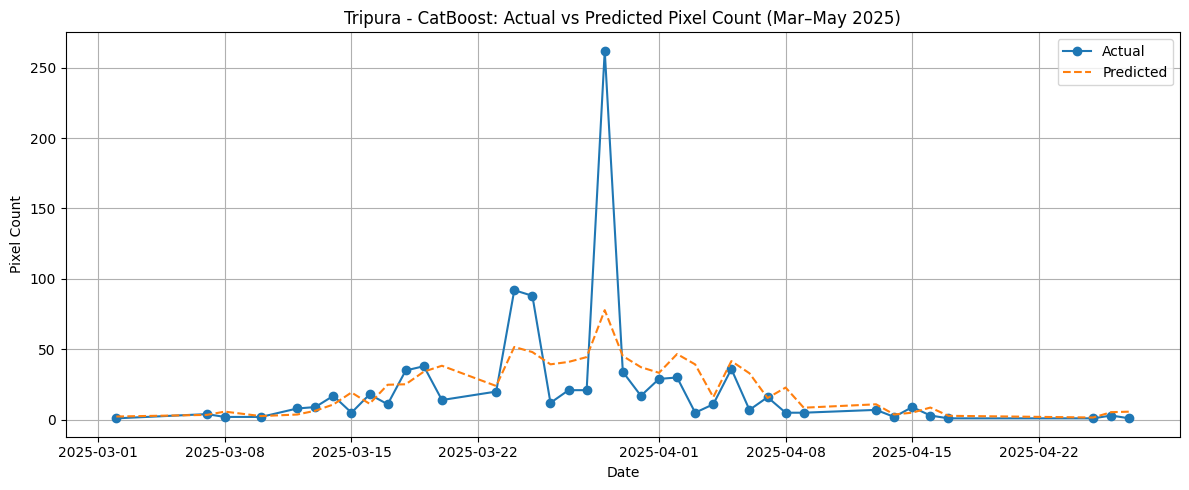

✅ 2025 predictions exported to 'catboost_predictions_2025.csv'


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from catboost import CatBoostRegressor

# --- Function: Feature Engineering ---
def add_features(df):
    df['day_of_year'] = df['date'].dt.dayofyear
    df['month'] = df['date'].dt.month
    df['year'] = df['date'].dt.year
    df['day_of_week'] = df['date'].dt.dayofweek
    df['week_of_year'] = df['date'].dt.isocalendar().week
    df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)

    df['lag1'] = df['pixel_count'].shift(1)
    df['lag3'] = df['pixel_count'].shift(3)
    df['lag7'] = df['pixel_count'].shift(7)
    df['rolling7'] = df['pixel_count'].rolling(window=7).mean()
    return df

# --- Step 1: Load full dataset (2012–2024) ---
full_df = pd.read_csv('/content/drive/MyDrive/Forest Only - Fire, LST, and CH4/Tripura_ForestOnly_FireMetrics_2012_2024.csv', parse_dates=['date'])
full_df['date'] = pd.to_datetime(full_df['date'], dayfirst=True)

# Apply feature engineering
full_df = add_features(full_df)
full_df.dropna(inplace=True)

# --- Step 2: Split data for 2024 validation ---
train_2024 = full_df[full_df['year'] <= 2023]
val_2024 = full_df[full_df['year'] == 2024]
val_2024 = val_2024[val_2024['month'].isin([3, 4, 5])]

# Define features and target
features = ['day_of_year', 'month', 'year', 'day_of_week', 'week_of_year', 'is_weekend',
            'lag1', 'lag3', 'lag7', 'rolling7']

X_train_2024 = train_2024[features]
y_train_2024 = train_2024['pixel_count']
X_val_2024 = val_2024[features]
y_val_2024 = val_2024['pixel_count']

# --- Step 3: Train and evaluate on 2024 ---
model_2024 = CatBoostRegressor(
    iterations=300,
    depth=8,
    learning_rate=0.03,
    loss_function='RMSE',
    verbose=50,
    random_seed=42
)
model_2024.fit(X_train_2024, y_train_2024)

y_pred_2024 = model_2024.predict(X_val_2024)
print("\n📊 CatBoost Evaluation on Mar–May 2024")
print(f"MAE: {mean_absolute_error(y_val_2024, y_pred_2024):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_val_2024, y_pred_2024)):.2f}")
print(f"MSE: {mean_squared_error(y_val_2024, y_pred_2024):.2f}")
print(f"R²: {r2_score(y_val_2024, y_pred_2024):.4f}")

# --- Plot 2024 ---
plt.figure(figsize=(12, 5))
plt.plot(val_2024['date'], y_val_2024, label='Actual', marker='o')
plt.plot(val_2024['date'], y_pred_2024, label='Predicted', linestyle='--')
plt.title('CatBoost: Actual vs Predicted Pixel Count (Mar–May 2024)')
plt.xlabel('Date')
plt.ylabel('Pixel Count')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# --- Step 4: Load 2025 data ---
df_2025 = pd.read_csv('/content/drive/MyDrive/Forest Only - Fire, LST, and CH4/Tripura_ForestOnly_FireMetrics_2025.csv', parse_dates=['date'])
df_2025['date'] = pd.to_datetime(df_2025['date'], dayfirst=True)
df_2025 = add_features(df_2025)
df_2025 = df_2025[df_2025['month'].isin([3, 4, 5])]
df_2025.dropna(inplace=True)

# Use 2012–2024 as training for 2025
train_2025 = full_df  # already has features

X_train_2025 = train_2025[features]
y_train_2025 = train_2025['pixel_count']
X_val_2025 = df_2025[features]
y_val_2025 = df_2025['pixel_count']

# --- Step 5: Train and evaluate on 2025 ---
model_2025 = CatBoostRegressor(
    iterations=300,
    depth=8,
    learning_rate=0.03,
    loss_function='RMSE',
    verbose=50,
    random_seed=42
)
model_2025.fit(X_train_2025, y_train_2025)

y_pred_2025 = model_2025.predict(X_val_2025)
print("\n📊 CatBoost Evaluation on Mar–May 2025")
print(f"MAE: {mean_absolute_error(y_val_2025, y_pred_2025):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_val_2025, y_pred_2025)):.2f}")
print(f"MSE: {mean_squared_error(y_val_2025, y_pred_2025):.2f}")
print(f"R²: {r2_score(y_val_2025, y_pred_2025):.4f}")

# --- Plot 2025 ---
plt.figure(figsize=(12, 5))
plt.plot(df_2025['date'], y_val_2025, label='Actual', marker='o')
plt.plot(df_2025['date'], y_pred_2025, label='Predicted', linestyle='--')
plt.title('Tripura - CatBoost: Actual vs Predicted Pixel Count (Mar–May 2025)')
plt.xlabel('Date')
plt.ylabel('Pixel Count')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

df_2025[['date']].assign(predicted_pixel_count=y_pred_2025).to_csv('/content/drive/MyDrive/Predicted csvs/Tripura_ForestOnlyFire_CatBoost_Prediction_2025.csv', index=False)
print("✅ 2025 predictions exported to 'catboost_predictions_2025.csv'")
